# Notebook 03 — Exploratory Data Analysis (EDA)

## Goal
This notebook explores patterns in Toronto traffic collisions:
- Trend by year/month/day/hour
- Location/division/neighbourhood hotspots
- Severity indicators (fatalities/injuries)
- Road user involvement (automobile, bicycle, pedestrian, etc.)
- Basic geo distribution (lat/long)

Dataset used: Cleaned collisions dataset from Notebook 02.


In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

print("Libraries loaded.")



Libraries loaded.


In [20]:

DATA_PATH = "../data/cleaned/Traffic_Collisions_Cleaned.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (772516, 23)


,OBJECTID,EVENT_UNIQUE_ID,OCC_DATE,OCC_MONTH,OCC_DOW,OCC_YEAR,OCC_HOUR,DIVISION,FATALITIES,INJURY_COLLISIONS,FTR_COLLISIONS,PD_COLLISIONS,HOOD_158,NEIGHBOURHOOD_158,LONG_WGS84,LAT_WGS84,AUTOMOBILE,MOTORCYCLE,PASSENGER,BICYCLE,PEDESTRIAN,x,y
0,1,GO-20148000028,2014-01-01 05:00:00,January,Wednesday,2014,17,D53,0,NO,YES,NO,099,Mount Pleasant East (99),-79.377616,43.701225,YES,NO,NO,NO,NO,-8.836276e+06,5.419322e+06
1,2,GO-20148004875,2014-01-01 05:00:00,January,Wednesday,2014,14,D32,0,NO,NO,YES,105,Lawrence Park North (105),-79.397589,43.726091,YES,NO,NO,NO,NO,-8.838499e+06,5.423152e+06
2,3,GO-20141260499,2014-01-01 05:00:00,January,Wednesday,2014,2,NSA,0,YES,NO,NO,NSA,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09
3,4,GO-20141260663,2014-01-01 05:00:00,January,Wednesday,2014,3,NSA,0,NO,NO,YES,NSA,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09
4,5,GO-20141261162,2014-01-01 05:00:00,January,Wednesday,2014,5,NSA,0,YES,NO,NO,NSA,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09


## 1. Basic Structure Check
We verify:
- shape (rows/columns)
- column names
- data types
- missing values
- duplicates


In [21]:
print("Rows, Columns:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n")
df.dtypes


Rows, Columns: (772516, 23)

Columns:
 ['OBJECTID', 'EVENT_UNIQUE_ID', 'OCC_DATE', 'OCC_MONTH', 'OCC_DOW', 'OCC_YEAR', 'OCC_HOUR', 'DIVISION', 'FATALITIES', 'INJURY_COLLISIONS', 'FTR_COLLISIONS', 'PD_COLLISIONS', 'HOOD_158', 'NEIGHBOURHOOD_158', 'LONG_WGS84', 'LAT_WGS84', 'AUTOMOBILE', 'MOTORCYCLE', 'PASSENGER', 'BICYCLE', 'PEDESTRIAN', 'x', 'y']

Data types:



OBJECTID               int64
EVENT_UNIQUE_ID       object
OCC_DATE              object
OCC_MONTH             object
OCC_DOW               object
OCC_YEAR               int64
OCC_HOUR               int64
DIVISION              object
FATALITIES             int64
INJURY_COLLISIONS     object
FTR_COLLISIONS        object
PD_COLLISIONS         object
HOOD_158              object
NEIGHBOURHOOD_158     object
LONG_WGS84           float64
LAT_WGS84            float64
AUTOMOBILE            object
MOTORCYCLE            object
PASSENGER             object
BICYCLE               object
PEDESTRIAN            object
x                    float64
y                    float64
dtype: object

In [22]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(3)

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct
})

missing_table[missing_table["missing_count"] > 0].head(30)


,missing_count,missing_percent


In [23]:
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)


Duplicate rows: 0


## 2. Date/Time Feature Preparation
We convert `OCC_DATE` into datetime and create:
- year, month, day of week, hour (if not already present)
This helps with time-based EDA.


In [24]:
# If OCC_DATE exists as string/object, parse it
if "OCC_DATE" in df.columns:
    df["OCC_DATE"] = pd.to_datetime(df["OCC_DATE"], errors="coerce")

# Create derived time features if not already present
if "OCC_YEAR" not in df.columns and "OCC_DATE" in df.columns:
    df["OCC_YEAR"] = df["OCC_DATE"].dt.year

if "OCC_MONTH" not in df.columns and "OCC_DATE" in df.columns:
    df["OCC_MONTH"] = df["OCC_DATE"].dt.month_name()

if "OCC_DOW" not in df.columns and "OCC_DATE" in df.columns:
    df["OCC_DOW"] = df["OCC_DATE"].dt.day_name()

# Hour might already be present; if not, try extracting
if "OCC_HOUR" not in df.columns and "OCC_DATE" in df.columns:
    df["OCC_HOUR"] = df["OCC_DATE"].dt.hour

df[["OCC_DATE","OCC_YEAR","OCC_MONTH","OCC_DOW","OCC_HOUR"]].head()


,OCC_DATE,OCC_YEAR,OCC_MONTH,OCC_DOW,OCC_HOUR
0,2014-01-01 05:00:00,2014,January,Wednesday,17
1,2014-01-01 05:00:00,2014,January,Wednesday,14
2,2014-01-01 05:00:00,2014,January,Wednesday,2
3,2014-01-01 05:00:00,2014,January,Wednesday,3
4,2014-01-01 05:00:00,2014,January,Wednesday,5


## 3. Target/Severity Quick Look
We check severity indicators:
- Fatalities distribution
- Injury collisions counts (YES/NO)
We also check if these variables have missing/invalid values.


In [25]:
if "FATALITIES" in df.columns:
    print(df["FATALITIES"].describe())
    print("\nValue counts (top):")
    print(df["FATALITIES"].value_counts().head(10))
else:
    print("FATALITIES column not found.")


count    772516.000000
mean          0.000860
std           0.030219
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           4.000000
Name: FATALITIES, dtype: float64

Value counts (top):
FATALITIES
0    771867
1       639
2         6
3         3
4         1
Name: count, dtype: int64


In [26]:
col = "INJURY_COLLISIONS"
if col in df.columns:
    print(df[col].value_counts(dropna=False))
else:
    print(f"{col} not found.")


INJURY_COLLISIONS
NO         667672
YES        104840
UNKNOWN         4
Name: count, dtype: int64


## 4. Trend Analysis Over Time
We analyze collision frequency over:
- Year
- Month
- Day of Week
- Hour of Day

This helps understand when collisions happen most.


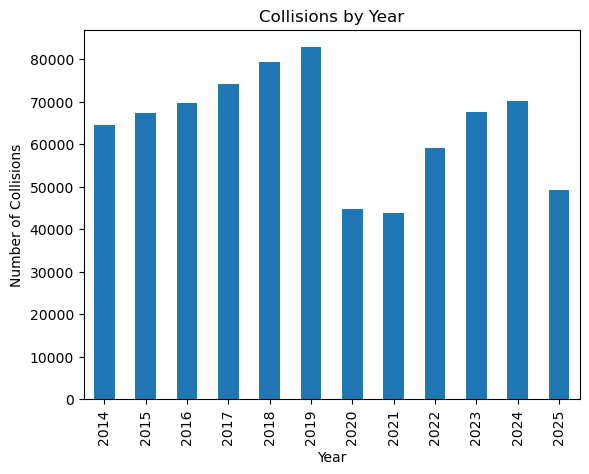

In [27]:
if "OCC_YEAR" in df.columns:
    year_counts = df["OCC_YEAR"].value_counts().sort_index()

    plt.figure()
    year_counts.plot(kind="bar")
    plt.title("Collisions by Year")
    plt.xlabel("Year")
    plt.ylabel("Number of Collisions")
    plt.show()
else:
    print("OCC_YEAR not found.")


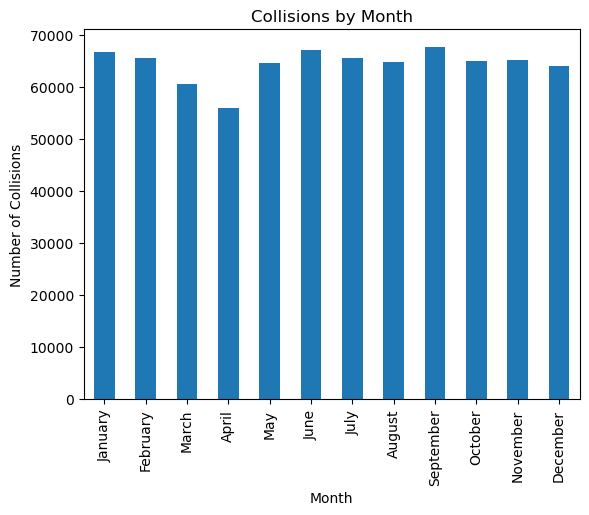

In [28]:
if "OCC_MONTH" in df.columns:
    month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
    month_counts = df["OCC_MONTH"].value_counts()

    month_counts = month_counts.reindex(month_order)

    plt.figure()
    month_counts.plot(kind="bar")
    plt.title("Collisions by Month")
    plt.xlabel("Month")
    plt.ylabel("Number of Collisions")
    plt.show()
else:
    print("OCC_MONTH not found.")


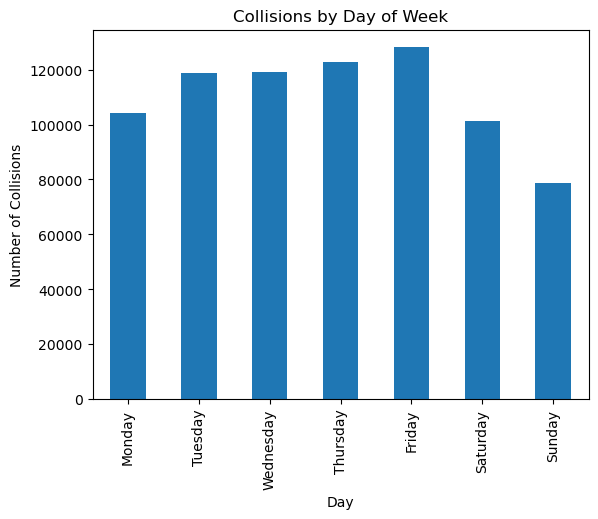

In [29]:
if "OCC_DOW" in df.columns:
    dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    dow_counts = df["OCC_DOW"].value_counts().reindex(dow_order)

    plt.figure()
    dow_counts.plot(kind="bar")
    plt.title("Collisions by Day of Week")
    plt.xlabel("Day")
    plt.ylabel("Number of Collisions")
    plt.show()
else:
    print("OCC_DOW not found.")


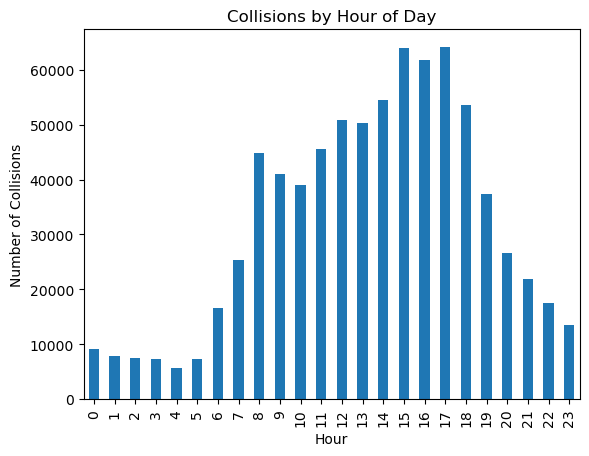

In [30]:
if "OCC_HOUR" in df.columns:
    hour_counts = df["OCC_HOUR"].value_counts().sort_index()

    plt.figure()
    hour_counts.plot(kind="bar")
    plt.title("Collisions by Hour of Day")
    plt.xlabel("Hour")
    plt.ylabel("Number of Collisions")
    plt.show()
else:
    print("OCC_HOUR not found.")


## 5. Location / Division Hotspots
We identify where collisions are most frequent:
- Police division
- Neighbourhood
- Hood
This helps detect high-risk areas.


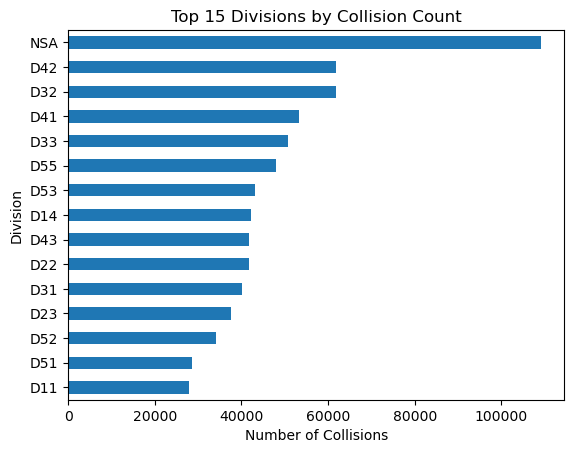

In [31]:
if "DIVISION" in df.columns:
    top_div = df["DIVISION"].value_counts().head(15)

    plt.figure()
    top_div.sort_values().plot(kind="barh")
    plt.title("Top 15 Divisions by Collision Count")
    plt.xlabel("Number of Collisions")
    plt.ylabel("Division")
    plt.show()
else:
    print("DIVISION not found.")


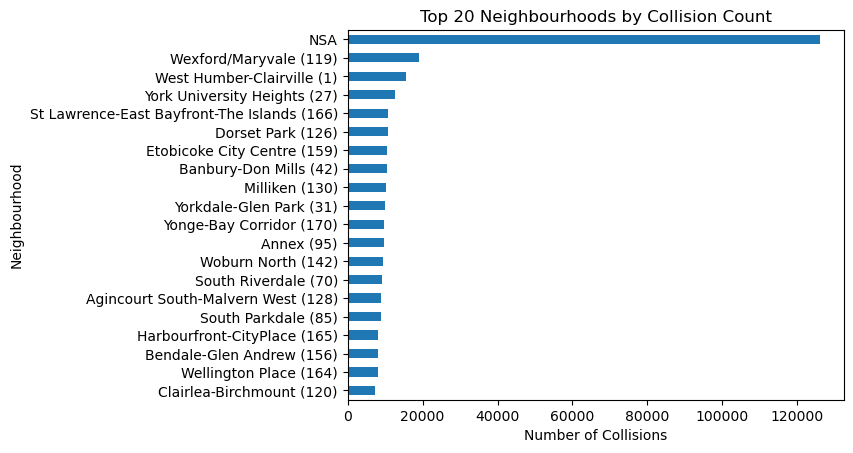

In [32]:
col = "NEIGHBOURHOOD_158"
if col in df.columns:
    top_hood = df[col].value_counts().head(20)

    plt.figure()
    top_hood.sort_values().plot(kind="barh")
    plt.title("Top 20 Neighbourhoods by Collision Count")
    plt.xlabel("Number of Collisions")
    plt.ylabel("Neighbourhood")
    plt.show()
else:
    print(f"{col} not found.")


## 6. Road User Involvement (Mode Columns)
Many Toronto collision datasets use YES/NO columns like:
- AUTOMOBILE, PASSENGER, PEDESTRIAN, BICYCLE, MOTORCYCLE, TRUCK, etc.

We calculate how many collisions involve each mode.


In [33]:
mode_cols = [c for c in df.columns if c.upper() in [
    "AUTOMOBILE","PASSENGER","PEDESTRIAN","BICYCLE","MOTORCYCLE","TRUCK","BUS","EMERG_VEH","AG_DRIV","OTHER"
]]

print("Detected mode columns:", mode_cols)

mode_counts = {}
for c in mode_cols:
    # count YES (case-insensitive)
    mode_counts[c] = (df[c].astype(str).str.upper() == "YES").sum()

mode_series = pd.Series(mode_counts).sort_values(ascending=False)
mode_series


Detected mode columns: ['AUTOMOBILE', 'MOTORCYCLE', 'PASSENGER', 'BICYCLE', 'PEDESTRIAN']


AUTOMOBILE    762134
PASSENGER      61384
PEDESTRIAN     19180
BICYCLE        12443
MOTORCYCLE      4553
dtype: int64

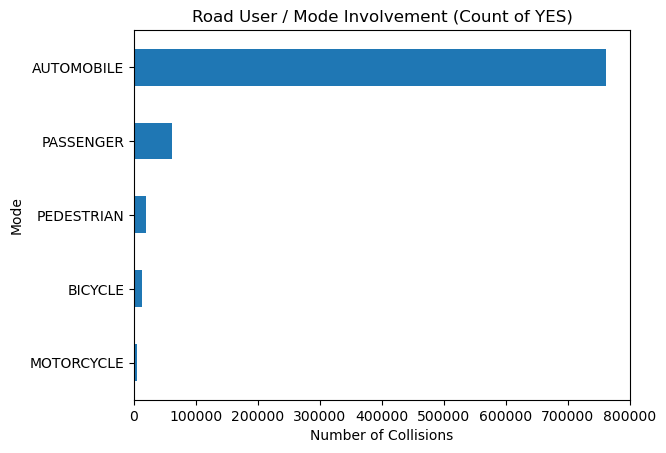

In [34]:
if len(mode_series) > 0:
    plt.figure()
    mode_series.sort_values().plot(kind="barh")
    plt.title("Road User / Mode Involvement (Count of YES)")
    plt.xlabel("Number of Collisions")
    plt.ylabel("Mode")
    plt.show()
else:
    print("No mode columns found in this dataset.")


## 7. Geo Distribution Check (Latitude/Longitude)
We check if geo columns exist and:
- validate coordinate ranges
- show a rough scatter plot


In [35]:
if "LAT_WGS84" in df.columns and "LONG_WGS84" in df.columns:
    print("LAT range:", df["LAT_WGS84"].min(), "to", df["LAT_WGS84"].max())
    print("LONG range:", df["LONG_WGS84"].min(), "to", df["LONG_WGS84"].max())

    # Filter likely valid Toronto ranges
    geo = df[(df["LAT_WGS84"].between(43.0, 44.0)) & (df["LONG_WGS84"].between(-80.5, -78.5))].copy()
    print("Valid geo rows:", geo.shape[0])

    geo.sample(5)
else:
    print("LAT_WGS84 / LONG_WGS84 not found.")


LAT range: 0.0 to 43.8531638931327
LONG range: -79.6392473469942 to 0.0
Valid geo rows: 646447


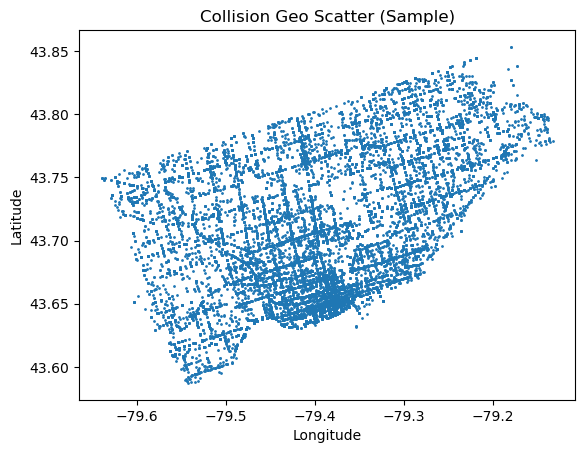

In [36]:
if "LAT_WGS84" in df.columns and "LONG_WGS84" in df.columns:
    geo = df[(df["LAT_WGS84"].between(43.0, 44.0)) & (df["LONG_WGS84"].between(-80.5, -78.5))].copy()
    
    sample_geo = geo.sample(min(20000, len(geo)), random_state=42)

    plt.figure()
    plt.scatter(sample_geo["LONG_WGS84"], sample_geo["LAT_WGS84"], s=1)
    plt.title("Collision Geo Scatter (Sample)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()


## 8. Correlation Check (Numeric Only)
We check correlation between numeric variables like:
- OCC_HOUR
- OCC_YEAR
- FATALITIES
- x/y or LAT/LONG (if present)

This is optional but useful for early understanding.


In [37]:
numeric_df = df.select_dtypes(include=["int64","float64"]).copy()
print("Numeric columns:", numeric_df.columns.tolist())

corr = numeric_df.corr(numeric_only=True)
corr


Numeric columns: ['OBJECTID', 'OCC_YEAR', 'OCC_HOUR', 'FATALITIES', 'LONG_WGS84', 'LAT_WGS84', 'x', 'y']


,OBJECTID,OCC_YEAR,OCC_HOUR,FATALITIES,LONG_WGS84,LAT_WGS84,x,y
OBJECTID,1.000000,0.994276,-0.002286,-0.002018,0.024747,-0.024772,0.024747,-0.024780
OCC_YEAR,0.994276,1.000000,-0.002225,-0.002234,0.021458,-0.021480,0.021458,-0.021488
OCC_HOUR,-0.002286,-0.002225,1.000000,-0.002726,-0.016211,0.016472,-0.016211,0.016495
FATALITIES,-0.002018,-0.002234,-0.002726,1.000000,-0.009315,0.009316,-0.009315,0.009316
LONG_WGS84,0.024747,0.021458,-0.016211,-0.009315,1.000000,-0.999986,1.000000,-0.999982
LAT_WGS84,-0.024772,-0.021480,0.016472,0.009316,-0.999986,1.000000,-0.999986,1.000000
x,0.024747,0.021458,-0.016211,-0.009315,1.000000,-0.999986,1.000000,-0.999982
y,-0.024780,-0.021488,0.016495,0.009316,-0.999982,1.000000,-0.999982,1.000000


In [38]:
if "FATALITIES" in numeric_df.columns:
    corr_target = corr["FATALITIES"].sort_values(ascending=False)
    corr_target
else:
    print("FATALITIES not available in numeric columns.")


## 9. Initial Observations (EDA Summary)

Based on the outputs above, the following early insights can be noted:

1. Dataset size is large (hundreds of thousands of rows), so sampling is recommended for heavy charts/geo plots.
2. Time-based trends (year/month/day/hour) show when collisions are most frequent and can help identify peak-risk windows.
3. Division and neighbourhood ranking helps identify high-collision hotspots (useful for resource planning and intervention).
4. Severity indicators like fatalities are usually heavily imbalanced (many zeros) which will impact modeling later.
5. Mode involvement columns (YES/NO) indicate what type of road users are commonly involved, and can support risk analysis.
6. Geo columns should be validated because some records may contain invalid coordinates (0,0 or out-of-range values).
7. Correlation results are only a quick check; deeper feature engineering and domain-driven analysis is needed for modeling.

Next step: finalize cleaning/imputation rules (Notebook 02) and then build modeling features.
